In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

In [13]:
alzheimers_data = pd.read_csv("alzheimers_disease_data.csv")
"""
Importing data frame
Arguments:
            alzheimers_data = pd.read_csv("alzheimers_disease_data.csv")
Returns:
            2149 rows and 35 columns of data on Alzheimer's patients
"""

'\nImporting data frame\nArguments:\n            alzheimers_data = pd.read_csv("alzheimers_disease_data.csv")\nReturns:\n            2149 rows and 35 columns of data on Alzheimer\'s patients\n'

In [14]:
alzheimers_data.dtypes

PatientID                      int64
Age                            int64
Gender                         int64
Ethnicity                      int64
EducationLevel                 int64
BMI                          float64
Smoking                        int64
AlcoholConsumption           float64
PhysicalActivity             float64
DietQuality                  float64
SleepQuality                 float64
FamilyHistoryAlzheimers        int64
CardiovascularDisease          int64
Diabetes                       int64
Depression                     int64
HeadInjury                     int64
Hypertension                   int64
SystolicBP                     int64
DiastolicBP                    int64
CholesterolTotal             float64
CholesterolLDL               float64
CholesterolHDL               float64
CholesterolTriglycerides     float64
MMSE                         float64
FunctionalAssessment         float64
MemoryComplaints               int64
BehavioralProblems             int64
A

In [15]:
print(alzheimers_data.describe())

         PatientID          Age       Gender    Ethnicity  EducationLevel  \
count  2149.000000  2149.000000  2149.000000  2149.000000     2149.000000   
mean   5825.000000    74.908795     0.506282     0.697534        1.286645   
std     620.507185     8.990221     0.500077     0.996128        0.904527   
min    4751.000000    60.000000     0.000000     0.000000        0.000000   
25%    5288.000000    67.000000     0.000000     0.000000        1.000000   
50%    5825.000000    75.000000     1.000000     0.000000        1.000000   
75%    6362.000000    83.000000     1.000000     1.000000        2.000000   
max    6899.000000    90.000000     1.000000     3.000000        3.000000   

               BMI      Smoking  AlcoholConsumption  PhysicalActivity  \
count  2149.000000  2149.000000         2149.000000       2149.000000   
mean     27.655697     0.288506           10.039442          4.920202   
std       7.217438     0.453173            5.757910          2.857191   
min      15.00

## Analysis 1

Correlation Score: -0.004234771200121317


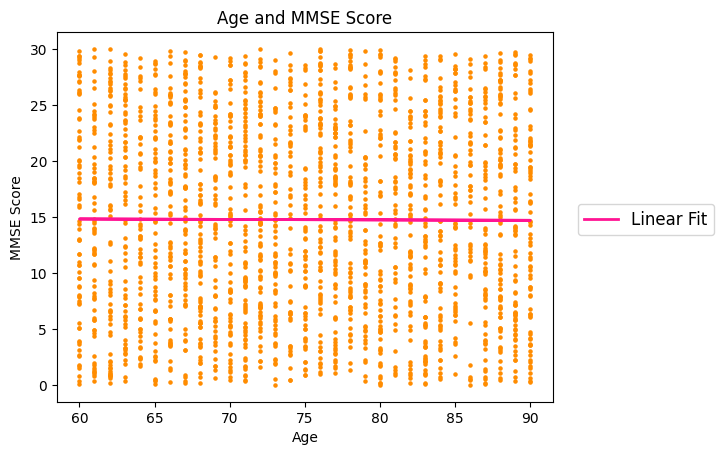

In [16]:
Age = alzheimers_data["Age"]
MMSE = alzheimers_data["MMSE"]

corr = scipy.stats.pearsonr(Age, MMSE)
print("Correlation Score:", corr[0])
linear_model = scipy.stats.linregress(Age, MMSE)
slope = linear_model.slope
intercept = linear_model.intercept
linear_fit = slope*Age+intercept

plt.scatter(alzheimers_data['Age'], alzheimers_data['MMSE'], s=5, color="darkorange")
plt.title("Age and MMSE Score")
plt.xlabel("Age")
plt.ylabel("MMSE Score")
plt.plot(Age, linear_fit, linewidth=2, color="deeppink", label="Linear Fit")
plt.legend(fontsize=12, loc=(1.05, 0.45))
plt.show()

## Analysis 2

In [17]:
alzheimers_corr = alzheimers_data.corr(numeric_only=True)
alzheimers_corr

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
PatientID,1.000000,0.002947,-0.043665,-0.007608,-0.001729,-0.034228,0.021907,-0.020733,-0.011424,-0.018490,...,0.025033,0.005748,-0.033700,-0.019787,0.004430,0.010772,-0.011987,0.029727,0.001448,0.041019
Age,0.002947,1.000000,0.028708,0.027745,-0.060560,-0.015677,0.020060,0.007323,-0.010249,-0.023386,...,0.005508,0.012343,0.038973,-0.038658,0.009002,0.027523,-0.009470,0.013900,-0.019279,-0.005488
Gender,-0.043665,0.028708,1.000000,-0.003660,-0.007070,0.005928,0.016650,0.004330,-0.035795,0.010942,...,0.033324,0.003880,0.006099,0.003865,-0.030583,0.017506,0.025919,-0.001636,-0.028537,-0.020975
Ethnicity,-0.007608,0.027745,-0.003660,1.000000,0.026516,-0.003176,0.031485,0.008363,0.020498,-0.018184,...,-0.004704,0.003687,-0.019363,0.010475,0.022431,-0.018132,-0.030035,0.019363,-0.034619,-0.014782
EducationLevel,-0.001729,-0.060560,-0.007070,0.026516,1.000000,-0.023514,-0.009904,-0.012646,-0.016703,0.017412,...,0.020269,-0.000165,0.010473,0.031934,-0.008168,-0.017568,-0.019950,0.013033,-0.008685,-0.043966
BMI,-0.034228,-0.015677,0.005928,-0.003176,-0.023514,1.000000,0.020437,-0.008997,0.000742,0.019922,...,-0.030501,0.029293,0.035276,-0.009788,-0.015859,-0.031840,-0.015901,-0.039400,0.071131,0.026343
Smoking,0.021907,0.020060,0.016650,0.031485,-0.009904,0.020437,1.000000,0.008363,0.010760,-0.002048,...,-0.031879,0.020339,-0.014763,-0.029233,0.004498,-0.028403,-0.009977,0.001741,0.018011,-0.004865
AlcoholConsumption,-0.020733,0.007323,0.004330,0.008363,-0.012646,-0.008997,0.008363,1.000000,0.021696,0.020117,...,-0.016483,-0.029418,0.013657,-0.008250,-0.032798,0.015521,0.019117,-0.002712,-0.024121,-0.007618
PhysicalActivity,-0.011424,-0.010249,-0.035795,0.020498,-0.016703,0.000742,0.010760,0.021696,1.000000,0.011085,...,-0.002419,0.008709,-0.014253,-0.013324,-0.009397,-0.020407,-0.013629,0.031169,0.009837,0.005945
DietQuality,-0.018490,-0.023386,0.010942,-0.018184,0.017412,0.019922,-0.002048,0.020117,0.011085,1.000000,...,-0.009700,0.012537,-0.014033,-0.007888,0.002628,-0.026271,0.029087,0.045737,0.006175,0.008506


([<matplotlib.axis.YTick at 0x137f92940>,
 [Text(0, 0, 'PatientID'),
  Text(0, 1, 'Age'),
  Text(0, 2, 'Gender'),
  Text(0, 3, 'Ethnicity'),
  Text(0, 4, 'EducationLevel'),
  Text(0, 5, 'BMI'),
  Text(0, 6, 'Smoking'),
  Text(0, 7, 'AlcoholConsumption'),
  Text(0, 8, 'PhysicalActivity'),
  Text(0, 9, 'DietQuality'),
  Text(0, 10, 'SleepQuality'),
  Text(0, 11, 'FamilyHistoryAlzheimers'),
  Text(0, 12, 'CardiovascularDisease'),
  Text(0, 13, 'Diabetes'),
  Text(0, 14, 'Depression'),
  Text(0, 15, 'HeadInjury'),
  Text(0, 16, 'Hypertension'),
  Text(0, 17, 'SystolicBP'),
  Text(0, 18, 'DiastolicBP'),
  Text(0, 19, 'CholesterolTotal'),
  Text(0, 20, 'CholesterolLDL'),
  Text(0, 21, 'CholesterolHDL'),
  Text(0, 22, 'CholesterolTriglycerides'),
  Text(0, 23, 'MMSE'),
  Text(0, 24, 'FunctionalAssessment'),
  Text(0, 25, 'MemoryComplaints'),
  Text(0, 26, 'BehavioralProblems'),
  Text(0, 27, 'ADL'),
  Text(0, 28, 'Confusion'),
  Text(0, 29, 'Disorientation'),
  Text(0, 30, 'PersonalityChanges

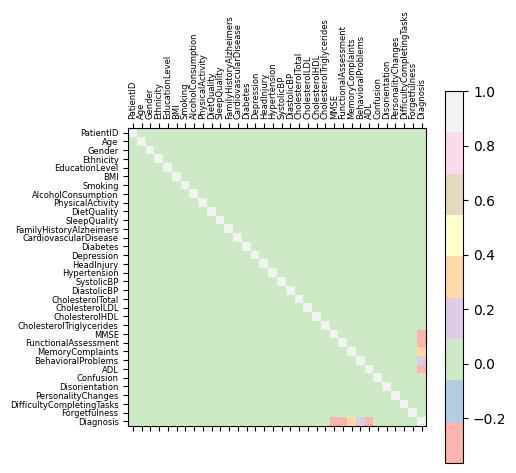

In [18]:
plt.matshow(alzheimers_corr, cmap="Pastel1")
plt.colorbar()
plt.xticks(range(len(alzheimers_corr.index)), alzheimers_corr.index, rotation=90, size=6)
plt.yticks(range(len(alzheimers_corr.index)), alzheimers_corr.index, size=6)

In [19]:
X = alzheimers_data[["Smoking","AlcoholConsumption", "PhysicalActivity", "DietQuality", "SleepQuality"]]
y = alzheimers_data["Diagnosis"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)
# Classifier
classifier = KNeighborsClassifier(n_neighbors = 2)
classifier.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=2)

In [20]:
prediction = classifier.predict(X_test)
print(prediction[1:100])

[0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 0]


In [21]:
accuracy = accuracy_score(y_test, prediction)
print(accuracy*100)

62.32558139534884


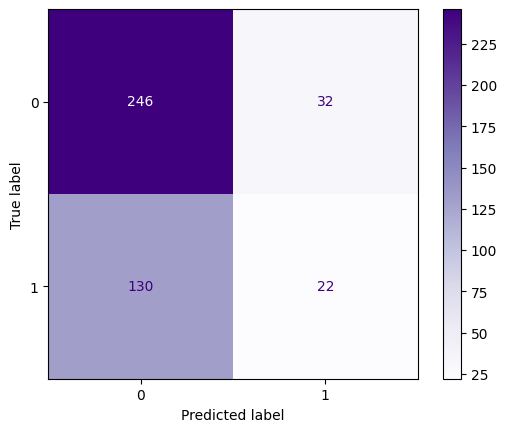

In [22]:
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test, cmap="Purples")

## Analysis 3

In [23]:
education_counts = alzheimers_data["EducationLevel"].value_counts()
education_counts

EducationLevel
1    854
2    636
0    446
3    213
Name: count, dtype: int64